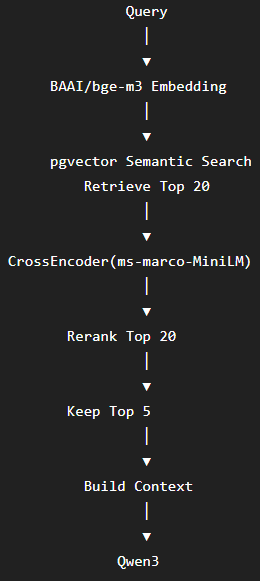

In [3]:
from sentence_transformers import SentenceTransformer, CrossEncoder
from pgvector.psycopg2 import register_vector
import psycopg2
import ollama

# ==========================================================
# Configuration
# ==========================================================

HOST = "localhost"
PORT = 5434
USER = "admin"
PASSWORD = "pass123"
DATABASE = "RAG_POC"

TABLE = "rag_chunks"

EMBED_MODEL = "BAAI/bge-m3"
RERANK_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
OLLAMA_MODEL = "qwen3:8b"

TOP_K_RETRIEVAL = 20
TOP_K_FINAL = 5

SEARCH_QUERY = "Alarm Logger Manager"

QUESTION = """
which figure number should i refer application bar configure for Alarm Logger Manager
"""

# ==========================================================
# Load Models
# ==========================================================

# print("=" * 80)
# print("Loading Models...")
# print("=" * 80)

embed_model = SentenceTransformer(EMBED_MODEL)

reranker = CrossEncoder(RERANK_MODEL)

# ==========================================================
# Create Query Embedding
# ==========================================================

query_embedding = embed_model.encode(
    SEARCH_QUERY,
    normalize_embeddings=True
).tolist()

embedding_str = "[" + ",".join(map(str, query_embedding)) + "]"

# ==========================================================
# PostgreSQL Connection
# ==========================================================

print("\nConnecting PostgreSQL...")

conn = psycopg2.connect(
    host=HOST,
    port=PORT,
    user=USER,
    password=PASSWORD,
    dbname=DATABASE
)

register_vector(conn)

cur = conn.cursor()

# ==========================================================
# Semantic Search
# ==========================================================

# print("\nRunning Semantic Search...")

sql = f"""
SELECT
    page_content,
    source,
    metadata,
    embedding <=> %s::vector AS distance
FROM {TABLE}
ORDER BY distance
LIMIT %s;
"""

cur.execute(
    sql,
    (
        embedding_str,
        TOP_K_RETRIEVAL
    )
)

rows = cur.fetchall()

cur.close()
conn.close()

if not rows:
    print("No documents found.")
    exit()

# print(f"\nRetrieved {len(rows)} chunks")

# ==========================================================
# Cross Encoder Reranking
# ==========================================================

# print("\nRunning CrossEncoder Reranking...")

pairs = [
    (SEARCH_QUERY, row[0])
    for row in rows
]

scores = reranker.predict(pairs)

reranked = []

for row, score in zip(rows, scores):

    page_content, source, metadata, distance = row

    reranked.append({
        "page_content": page_content,
        "source": source,
        "metadata": metadata,
        "distance": distance,
        "rerank_score": float(score)
    })

reranked.sort(
    key=lambda x: x["rerank_score"],
    reverse=True
)

reranked = reranked[:TOP_K_FINAL]

# ==========================================================
# Print Reranked Results
# ==========================================================

# print("\n")
# print("=" * 80)
# print("TOP RERANKED CHUNKS")
# print("=" * 80)

context = ""

for i, doc in enumerate(reranked, start=1):

    # print(f"\nRank : {i}")
    # print(f"Vector Distance : {doc['distance']:.5f}")
    # print(f"Reranker Score : {doc['rerank_score']:.5f}")
    # print(f"Source : {doc['source']}")
    # print(f"Metadata : {doc['metadata']}")
    # print("-" * 80)

    context += doc["page_content"] + "\n\n"

# ==========================================================
# Prompt
# ==========================================================

prompt = f"""
You are a RAG assistant.

Answer ONLY from the supplied context.

If the answer is not present in the context,
reply exactly:

Data is not available.

Context:
{context}

Question:
{QUESTION}

Rules:

1. Use ONLY the context.
2. Do NOT use outside knowledge.
3. Return only the requested information.
4. Do not explain.
5. Do not summarize.


Answer:
"""

# ==========================================================
# Ask Ollama
# ==========================================================

print("\nGenerating Answer...\n")

response = ollama.chat(
    model=OLLAMA_MODEL,
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)

# ==========================================================
# Final Output
# ==========================================================

print("=" * 80)
print("FINAL ANSWER")
print("=" * 80)



with open("../console.md", "w", encoding="utf-8") as f:
    f.write(response["message"]["content"] + "\n")

print(response["message"]["content"])


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 10932.43it/s]



Connecting PostgreSQL...

Generating Answer...

FINAL ANSWER
Figure 6
